<a href="https://colab.research.google.com/github/mozaloom/Computer-Vision/blob/main/cv_assignment2_mohammedzaloom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OpenCV - implementation of Image Processing Techniques

**Importing Libraries**

In [ ]:
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import cv2 as cv

**Reading Images & Templates**

In [ ]:
template=cv.imread('images/template.jpg',0)
images=['images/image1.jpg','images/image2.jpg','images/image3.jpg','images/image4.jpg']
BoundingBoxes=[]
temp=[]



**Iterate through our four images using a loop**


In [ ]:
for image in images:
    image=cv.imread(image,0)
    scale = 1

    while (scale  < 2.1 ):

        h = int(template.shape[0] * scale )
        w = int(template.shape[1] * scale )

        if(h<image.shape[0] and w<image.shape[1]): # Ensure the template image size is within the bounds of our image to prevent errors
            d = (w, h)

            resized = cv.resize(template, d, interpolation=cv.INTER_AREA)
            img = image.copy()
            result = cv.matchTemplate(img , resized, cv.TM_CCOEFF_NORMED)

            (minVal, maxVal, minLoc, maxLoc) = cv.minMaxLoc(result)

            if(maxVal>.5):

                (startX, startY) = maxLoc
                endX = startX + resized.shape[1]
                endY = startY + resized.shape[0]

                BoundingBoxes.append((startX, startY,endX, endY))


        else:

            break
        scale += .1

**Draw Rectangles based on the BoundingBoxes array**

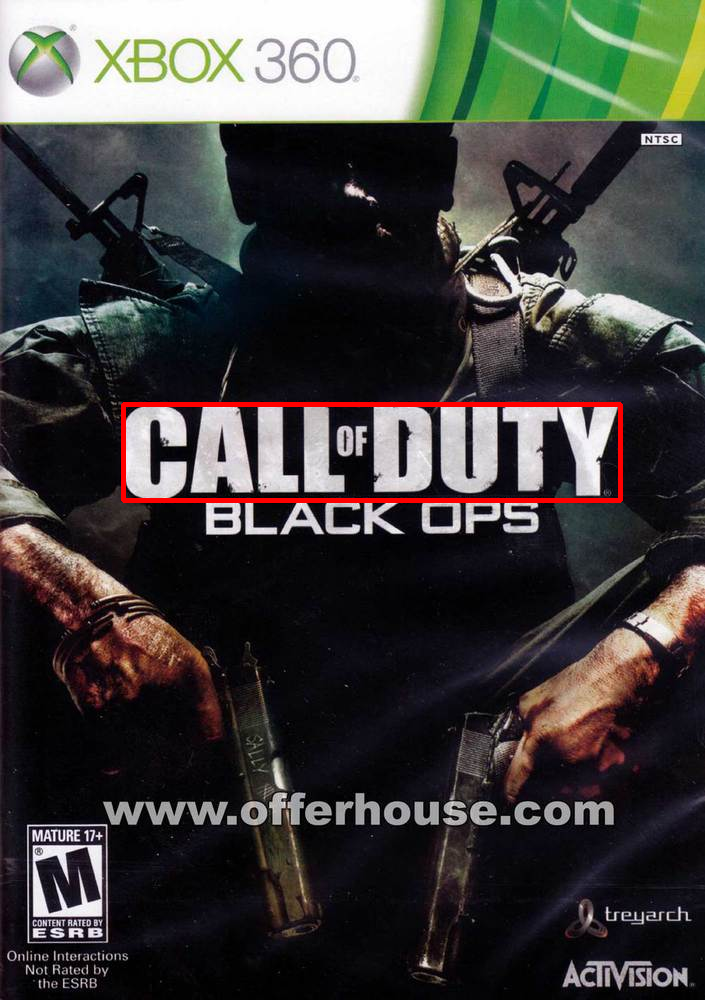

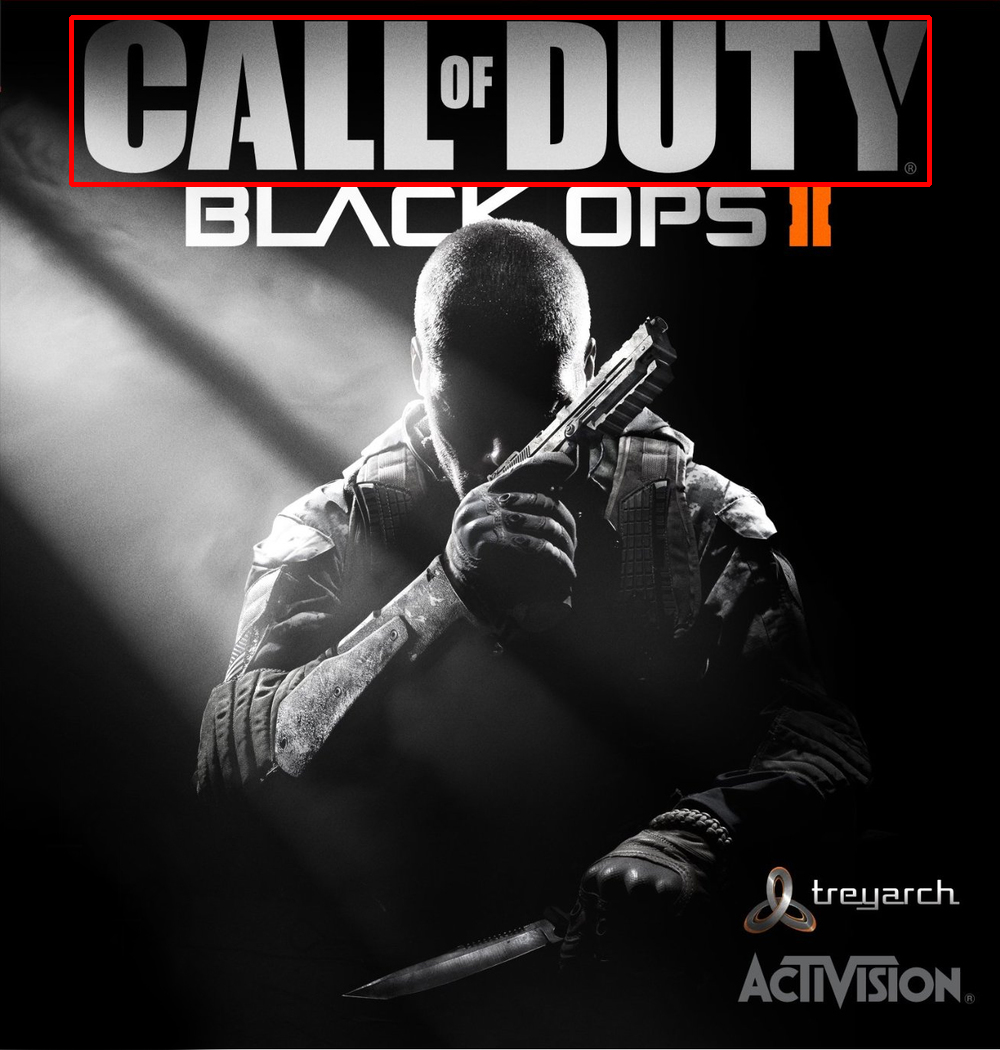

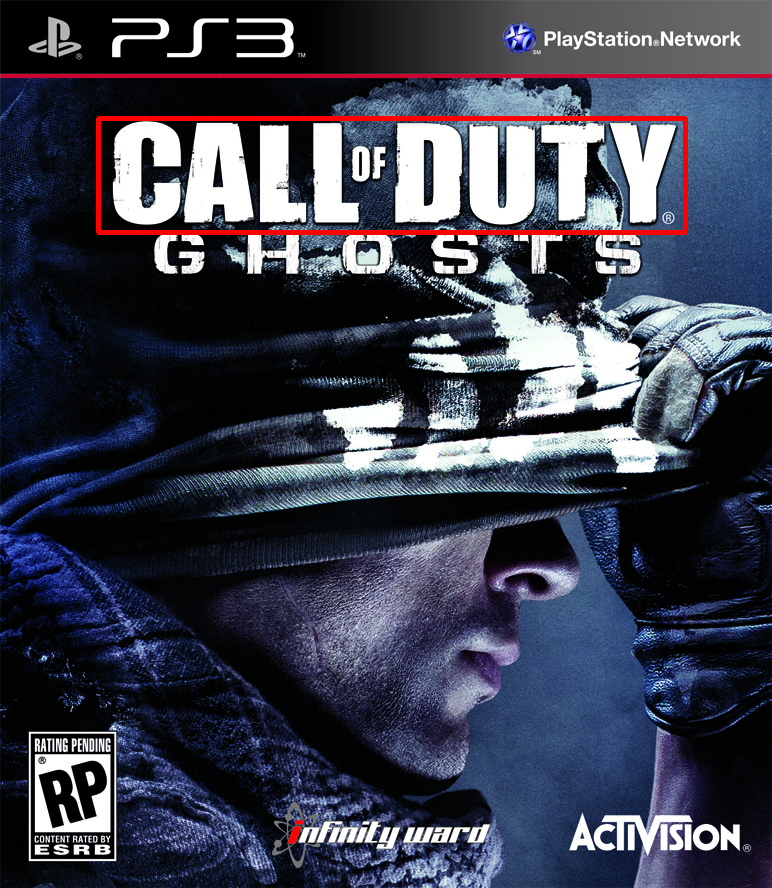

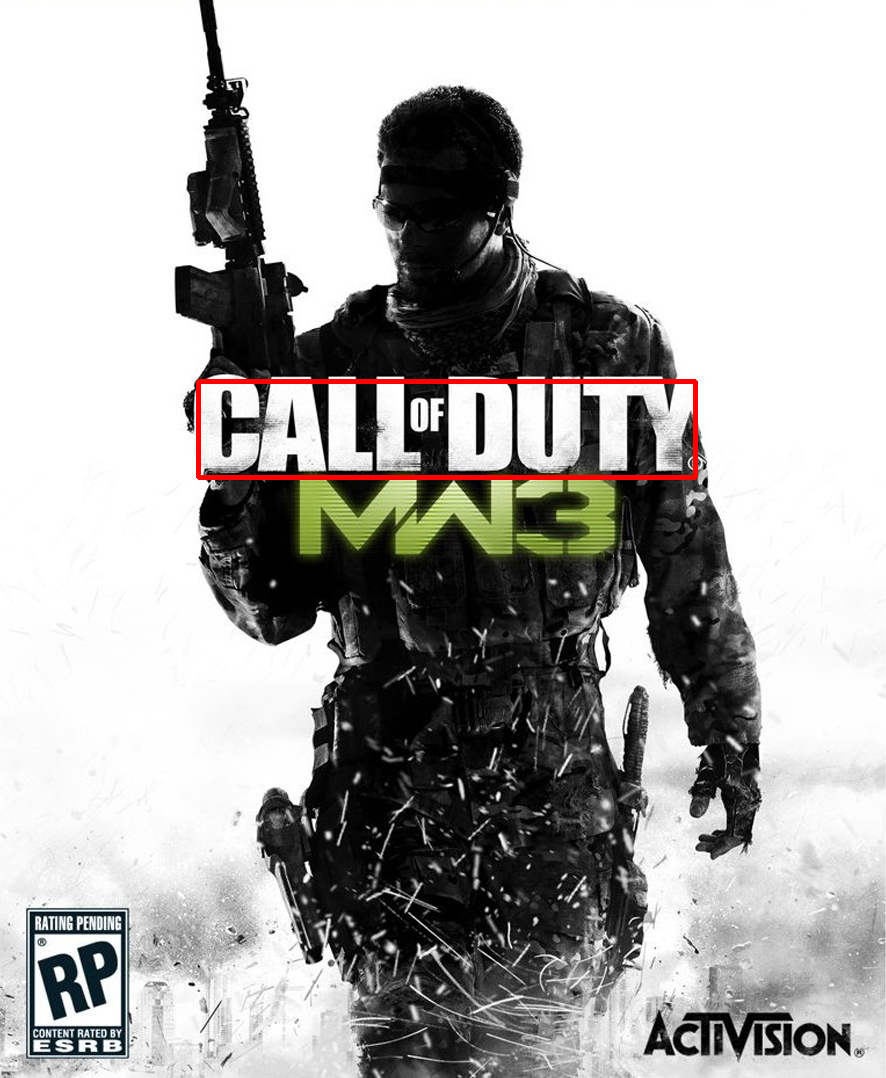

In [ ]:
for counter,image in enumerate(images):

    image = cv.imread(image)

    rec=cv.rectangle(image, (BoundingBoxes[counter][0], BoundingBoxes[counter][1]), (BoundingBoxes[counter][2], BoundingBoxes[counter][3]), (0, 0, 255), 3)

    cv2_imshow(image)